# Notebook 01: Baseline ResNet-18 on CIFAR-10

This notebook trains a CIFAR-adapted ResNet-18 using standard cross-entropy on clean CIFAR-10. It is the reference model for clean accuracy and corruption robustness comparisons.

Expected role in the project:

- Establish the clean-data baseline.
- Save training curves and best checkpoint.
- Provide the reference error used for relative mCE-style comparison.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
import torch
import matplotlib.pyplot as plt

from robust_cifar.data import make_cifar10_loaders, CIFAR10_CLASSES
from robust_cifar.models import build_resnet18_cifar, count_parameters
from robust_cifar.train import get_device, seed_everything

seed_everything(42)
device = get_device()
device

device(type='cuda')

## Dataset and Loader

CIFAR-10 has 50,000 training images and 10,000 test images across 10 classes.

In [2]:
train_loader, test_loader = make_cifar10_loaders(
    data_dir=PROJECT_ROOT / "data",
    batch_size=64,
    num_workers=2,
    mode="baseline",
    download=True,
)
len(train_loader.dataset), len(test_loader.dataset), CIFAR10_CLASSES

Files already downloaded and verified
Files already downloaded and verified


(50000,
 10000,
 ('airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck'))

## Model

The first ResNet convolution is changed to a 3x3 stride-1 convolution and max-pooling is removed, which is standard for 32x32 CIFAR images.

In [3]:
model = build_resnet18_cifar()
print(model)
print(f"Trainable parameters: {count_parameters(model):,}")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

## Training

For a quick smoke test, set `EPOCHS = 1`. For final project numbers use 50-100 epochs.

In [4]:
from robust_cifar.train import train_baseline

EPOCHS = 100
history = train_baseline(
    model,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    lr=0.01,
    device=device,
    output_dir=PROJECT_ROOT / "checkpoints",
    run_name="resnet18_baseline",
)
metrics_df = (
    pd.DataFrame(history)[["epoch", "train_loss", "train_accuracy", "val_loss", "val_accuracy"]]
    .rename(columns={"val_loss": "test_loss", "val_accuracy": "test_accuracy"})
)

for row in metrics_df.itertuples(index=False):
    print(
        f"Epoch {int(row.epoch):03d} | "
        f"Train Loss: {row.train_loss:.4f} | Train Acc: {row.train_accuracy:.4f} | "
        f"Test Loss: {row.test_loss:.4f} | Test Acc: {row.test_accuracy:.4f}"
    )

metrics_df

resnet18_baseline epoch 1/100:   0%|          | 0/782 [00:09<?, ?it/s]

resnet18_baseline epoch 2/100:   0%|          | 0/782 [00:09<?, ?it/s]

resnet18_baseline epoch 3/100:   0%|          | 0/782 [00:10<?, ?it/s]

resnet18_baseline epoch 4/100:   0%|          | 0/782 [00:10<?, ?it/s]

resnet18_baseline epoch 5/100:   0%|          | 0/782 [00:09<?, ?it/s]

...

resnet18_baseline epoch 98/100:   0%|          | 0/782 [00:07<?, ?it/s]

resnet18_baseline epoch 99/100:   0%|          | 0/782 [00:07<?, ?it/s]

resnet18_baseline epoch 100/100:   0%|          | 0/782 [00:07<?, ?it/s]

Epoch 001 | Train Loss: 1.5129 | Train Acc: 0.4530 | Test Loss: 1.2438 | Test Acc: 0.5643
Epoch 002 | Train Loss: 0.9882 | Train Acc: 0.6484 | Test Loss: 0.8587 | Test Acc: 0.7014
Epoch 003 | Train Loss: 0.7594 | Train Acc: 0.7333 | Test Loss: 0.7308 | Test Acc: 0.7536
Epoch 004 | Train Loss: 0.6353 | Train Acc: 0.7804 | Test Loss: 0.6758 | Test Acc: 0.7743
Epoch 005 | Train Loss: 0.5648 | Train Acc: 0.8058 | Test Loss: 0.6344 | Test Acc: 0.7873
Epoch 006 | Train Loss: 0.4978 | Train Acc: 0.8273 | Test Loss: 0.5348 | Test Acc: 0.8125
Epoch 007 | Train Loss: 0.4599 | Train Acc: 0.8405 | Test Loss: 0.5116 | Test Acc: 0.8243
Epoch 008 | Train Loss: 0.4182 | Train Acc: 0.8549 | Test Loss: 0.5142 | Test Acc: 0.8258
Epoch 009 | Train Loss: 0.3846 | Train Acc: 0.8669 | Test Loss: 0.4531 | Test Acc: 0.8465
Epoch 010 | Train Loss: 0.3600 | Train Acc: 0.8756 | Test Loss: 0.4807 | Test Acc: 0.8462
Epoch 011 | Train Loss: 0.3319 | Train Acc: 0.8855 | Test Loss: 0.4643 | Test Acc: 0.8477
Epoch 012 

,epoch,train_loss,train_accuracy,test_loss,test_accuracy
0,1,1.512925,0.45300,1.243752,0.5643
1,2,0.988209,0.64844,0.858656,0.7014
2,3,0.759353,0.73332,0.730837,0.7536
3,4,0.635316,0.78044,0.675798,0.7743
4,5,0.564819,0.80582,0.634414,0.7873
...,...,...,...,...,...
95,96,0.001688,0.99990,0.215692,0.9442
96,97,0.001859,0.99986,0.216970,0.9428
97,98,0.001654,0.99992,0.217725,0.9450
98,99,0.001626,0.99992,0.218740,0.9443


## Training and Testing Accuracy Comparison

The table above reports epoch, loss, and accuracy for both training and testing data. The graph below compares training accuracy against testing accuracy across epochs.

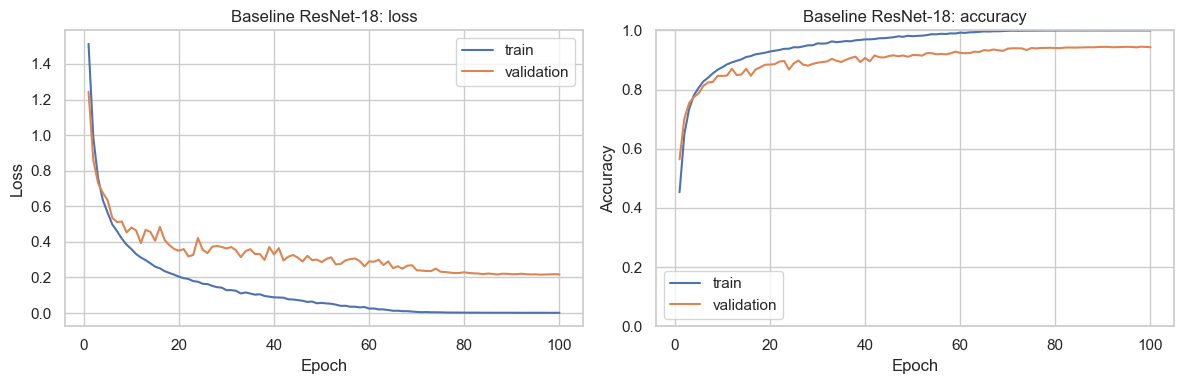

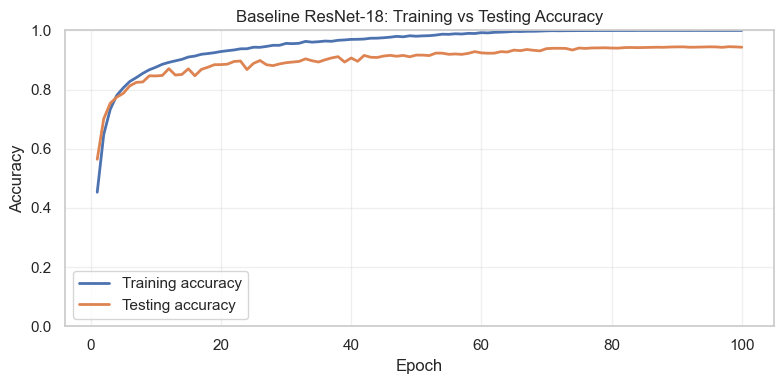

In [5]:
from robust_cifar.visualize import plot_training_history

history_df = pd.DataFrame(history)
plot_training_history(
    history_df,
    title="Baseline ResNet-18",
    output_path=PROJECT_ROOT / "reports" / "figures" / "baseline_training.png",
)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(metrics_df["epoch"], metrics_df["train_accuracy"], label="Training accuracy", linewidth=2)
ax.plot(metrics_df["epoch"], metrics_df["test_accuracy"], label="Testing accuracy", linewidth=2)
ax.set_title("Baseline ResNet-18: Training vs Testing Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports" / "figures" / "baseline_train_test_accuracy.png", dpi=180, bbox_inches="tight")
plt.show()